In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv('전체병합.csv',index_col=0)

건설사 TOP9
=

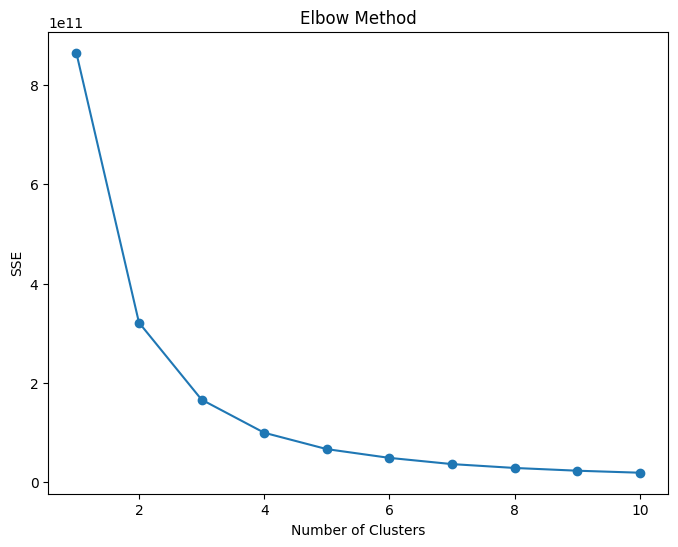

In [3]:
# 엘보우 메서드를 통한 최적 군집 개수 탐색
sse = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(df[['평당가격']])
    sse.append(kmeans.inertia_)  # 군집 내 SSE 값 저장

# SSE 그래프 그리기
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.show()

In [4]:
# K-Means 모델 생성
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['평당가격']])

# # 'Cluster' 열 원핫 인코딩
# cluster_encoded = pd.get_dummies(df['Cluster'], prefix='Cluster')

# # 기존 데이터프레임과 원핫 인코딩 결과를 합침
# df = pd.concat([df, cluster_encoded], axis=1)

# 'Cluster' 열 제거 (원핫 인코딩된 열이 이미 추가되었으므로)
df.drop(['건설사'], axis=1, inplace=True)

/home/t6user5/.conda/envs/example/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


난방 원핫인코딩
=

In [5]:
df['난방종류'] = df['난방'].apply(lambda x: 1 if x == 'HT001' else 0)
df.drop('난방', axis=1, inplace=True)  # '난방' 열 제거

In [6]:
df.to_csv('전체병합_전처리.csv')

heat map
=

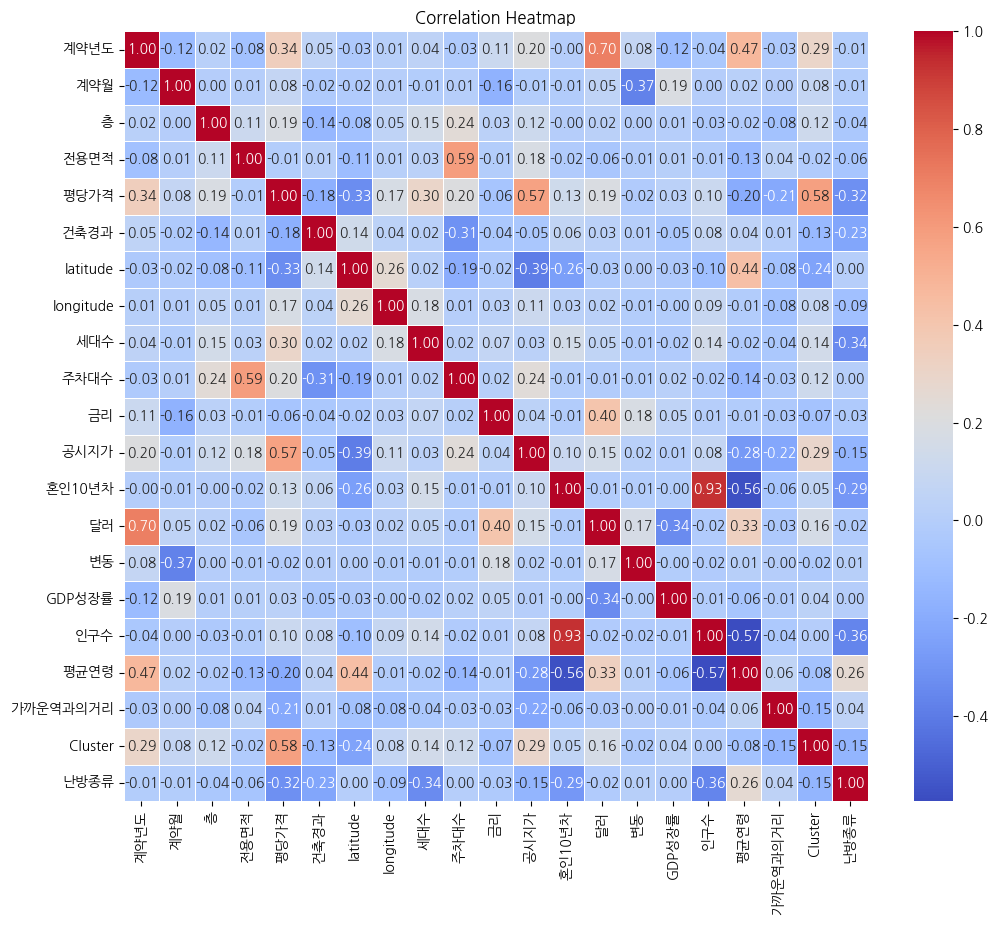

In [11]:
plt.rc('font', family='NanumGothic')
plt.figure(figsize=(12, 10))

# 피어슨 상관계수 계산
correlation_matrix = df.drop(columns='구').corr()

# 히트맵 그리기
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

VIF
=

In [8]:
X = df.drop(columns=['구','평당가격']) #독립변수
y = df['평당가격'] # 종속변수

# VIF 출력을 위한 데이터 프레임 형성
vif = pd.DataFrame()

# VIF 값과 각 Feature 이름에 대해 설정
vif["VIF Factor"] = [format(variance_inflation_factor(X.values, i),'f') for i in range(X.shape[1])]
vif["features"] = X.columns 

# VIF 값이 높은 순으로 정렬
vif = vif.sort_values(by="VIF Factor", ascending=False)
vif = vif.reset_index().drop(columns='index')
vif

,VIF Factor,features
0,987311.088584,latitude
1,980.624082,달러
2,9.870021,주차대수
3,6.972180,금리
4,6.669033,계약월
5,6.404516,건축경과
6,5.968153,공시지가
7,4.984361,난방종류
8,4.062318,가까운역과의거리
9,3251.436465,평균연령


OLS
=

In [9]:
from sklearn.preprocessing import StandardScaler

# train, test 데이터 분리 (8 : 2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=34)

# 모델 형성 및 결과 출력
model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   평당가격   R-squared (uncentered):                   0.928
Model:                            OLS   Adj. R-squared (uncentered):              0.928
Method:                 Least Squares   F-statistic:                          1.398e+05
Date:                Sun, 27 Aug 2023   Prob (F-statistic):                        0.00
Time:                        21:28:01   Log-Likelihood:                     -1.8288e+06
No. Observations:              218214   AIC:                                  3.658e+06
Df Residuals:                  218194   BIC:                                  3.658e+06
Df Model:                          20                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
계약년도          71.0520      1.506     47.185      0.000      68.101      74.003
계약월            5.2709      0.820      6.430      0.000       3.664       6.878
층              9.7111      0.375     25.877      0.000       8.976      10.447
전용면적         -28.0848      0.312    -90.003      0.000     -28.696     -27.473
건축경과         -23.5927      0.293    -80.503      0.000     -24.167     -23.018
latitude   -5502.3961     59.810    -91.998      0.000   -5619.622   -5385.170
longitude    522.5785     25.414     20.562      0.000     472.767     572.390
세대수            0.2895      0.002    132.160      0.000       0.285       0.294
주차대수         296.4395      5.729     51.745      0.000     285.211     307.668
금리          -384.4826      4.148    -92.685      0.000    -392.613    -376.352
공시지가           0.7894      0.004    202.645      0.000       0.782       0.797
혼인10년차        -0.3577      0.008    -42.664      0.000      -0.374      -0.341
달러             3.7363      0.061     61.371      0.000       3.617       3.856
변동            -6.9332      1.273     -5.444      0.000      -9.429      -4.437
GDP성장률        92.2899      2.098     43.982      0.000      88.177      96.403
인구수            0.0016    6.6e-05     24.167      0.000       0.001       0.002
평균연령         -81.9165      3.007    -27.237      0.000     -87.811     -76.022
가까운역과의거리    -380.2717      6.629    -57.362      0.000    -393.265    -367.278
Cluster      555.3576      2.815    197.303      0.000     549.841     560.874
난방종류        -750.9892      6.000   -125.166      0.000    -762.749    -739.229
==============================================================================
Omnibus:                    75055.463   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           569269.948
Skew:                           1.455   Prob(JB):                         0.00
Kurtosis:                      10.359   Cond. No.                     1.23e+07
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 1.23e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

산점도
=

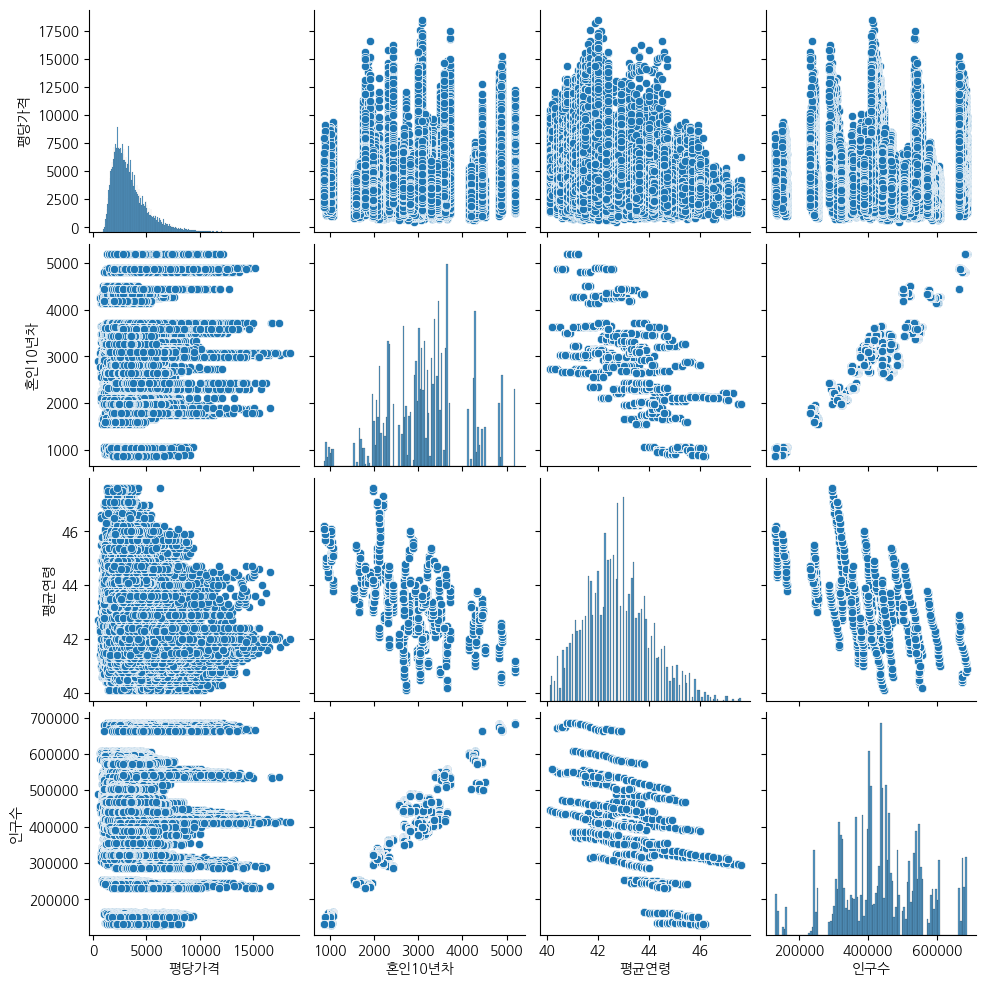

In [10]:
rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False
sns.pairplot(df[['평당가격','혼인10년차','평균연령','인구수']])